# **0. Load Preliminary Functions**


## Problem 1: Proof NLL = Cross-Entropy for binary

We change the notation of problem 1 since it's ambiguous. We use $\textbf{x}$ and $x_i$ to represent the random variables, and $\textbf{y}$ and $y_i$ to represent the value of an observation (i.e. a sample). We define the output of the model for $\mathbf{y}=[y_1, y_2, \cdots, y_n]$ at step $i$ as $q_i(y_{\lt i})$, thus:

$$
\begin{aligned}
q_i(y_{\lt i}) &= p(x_i=1|x_{\lt i} =y_{\lt i}) \\
1-q_i(y_{\lt i}) &= p(x_i=0|x_{\lt i} =y_{\lt i})
\end{aligned}
$$

Then we have the definition of NLL and cross-entropy loss for $\textbf{y}$:

$$
\begin{aligned}
\mathrm{NLL}(\textbf{y}) &= -\sum_{i=1}^T \log p(x_i=y_i|x_{\lt i} =y_{\lt i})\\
\mathrm{Loss}_{\mathrm{ce}}(\textbf{y}) &= -\sum_{i=1}^T \left(y_i \log q_i(y_{\lt i}) + (1-y_i) \log(1-q_i(y_{\lt i}))  \right)
\end{aligned}
$$

For $y_i=0$, we have

$$
\begin{aligned}
&y_i\log q_i(y_{\lt i}) + (1-y_i)\log (1-q_i(y_{\lt i})) \\
=& \log(1-q_i(y_{\lt i})) \\
=& \log(p(x_i=0|x_{\lt i} =y_{\lt i})) \\
=& \log(p(x_i=y_i|x_{\lt i} =y_{\lt i}))
\end{aligned}
$$

For $y_i=1$, we have

$$
\begin{aligned}
&y_i\log q_i(y_{\lt i}) + (1-y_i)\log (1-q_i(y_{\lt i})) \\
=& \log(q_i(y_{\lt i})) \\
=& \log(p(x_i=1|x_{\lt i} =y_{\lt i})) \\
=& \log(p(x_i=y_i|x_{\lt i} =y_{\lt i}))
\end{aligned}
$$

So we have for any $y_i$：

$$
y_i\log q_i(y_{\lt i}) + (1-y_i)\log (1-q_i(y_{\lt i})) = \log(p(x_i=y_i|x_{\lt i} =y_{\lt i}))
$$

Sum both sides from $i=1$ to $T$, we get $\mathrm{Loss}_{\mathrm{ce}}(\mathbf{y})=\mathrm{NLL}(\mathbf{y})$.


# a. Import Libraries and Functions


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device('cpu')

print(device)

print("cuda available:", torch.cuda.is_available())
print("torch version:", torch.__version__)
print("CUDA runtime in wheel:", torch.version.cuda)
print("cuDNN version:", torch.backends.cudnn.version())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))
    x = torch.randn(4096, 4096, device='cuda')
    y = x @ x
    torch.cuda.synchronize()
    print("ok, matmul done on:", y.device)

cuda


# b. MNIST Data Loader


In [2]:
def binarize_image(tensor):
    return (tensor > 0.5).float()


tensor_transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Lambda(binarize_image)]
)

batch_size = 128
train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=tensor_transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=tensor_transform
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False
)

for images, labels in train_loader:
    print(f"Image batch dimensions: {images.shape}")
    print(f"Label batch dimensions: {labels.shape}")
    break


Image batch dimensions: torch.Size([128, 1, 28, 28])
Label batch dimensions: torch.Size([128])


# **1. PixelCNN**

# a. Training Function


In [3]:
bce = F.binary_cross_entropy


def train(dataloader, model, optimizer, epochs):
    losses = []

    for epoch in tqdm(range(epochs), desc="Epochs"):
        running_loss = 0.0
        batch_progress = tqdm(dataloader, desc="Batches", leave=False)

        for iter, (images, labels) in enumerate(batch_progress):
            images = images.to(device)
            tgt = images.clone()
            pred = model(images)
            loss = bce(pred, tgt)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            avg_loss = running_loss * batch_size / len(train_dataset)
            losses.append(loss.item())

        tqdm.write(
            f"----\nEpoch [{epoch + 1}/{epochs}], Average Loss: {avg_loss:.4f}\n"
        )

    return losses


# b. Masked Convolution


In [4]:
# Check nn.Conv2d usage

demo_conv2d = nn.Conv2d(
    in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1
)

print(demo_conv2d.weight.shape)

torch.Size([16, 3, 3, 3])


In [5]:
from typing import Literal


class MaskedConv2d(nn.Conv2d):
    ##################
    ### Problem 2(a): Implement MaskedConv2d
    def __init__(self, mask_type: Literal["A", "B"], *args, **kwargs):
        super().__init__(*args, **kwargs)

        # For PixelCNN, k * k or 1 * k
        kernel_h, kernel_w = self.kernel_size

        assert kernel_h % 2 == 1 and kernel_w % 2 == 1, "Kernel size must be odd."
        assert self.stride[0] == 1 and self.stride[1] == 1, "Stride must be 1."
        assert self.padding[0] == kernel_h // 2 and self.padding[1] == kernel_w // 2, (
            "Padding must be kernel_size // 2."
        )

        center_h = kernel_h // 2
        center_w = kernel_w // 2
        start_col = center_w if mask_type == "A" else center_w + 1

        mask = torch.ones(kernel_h, kernel_w)
        mask[center_h, start_col:] = 0
        if center_h + 1 < kernel_h:
            mask[center_h + 1 :, :] = 0

        self.register_buffer("mask", mask)

    def forward(self, x):
        masked_weight = self.weight * self.mask
        return F.conv2d(x, masked_weight, self.bias, self.stride, self.padding)

    ##################


# c. Model


In [ ]:
class PixelCNN(nn.Module):
    ##################
    ### Problem 2(b): Implement PixelCNN
    @staticmethod
    def conv_block(
        mask_type, in_channels, out_channels, kernel_size, padding=None, stride=1
    ):
        if padding is None:
            padding = kernel_size // 2
        return nn.Sequential(
            MaskedConv2d(
                mask_type=mask_type,
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def __init__(self, in_channels=1, hidden_features=128, out_channels=1):
        super().__init__()
        self.blocks = nn.ModuleList([
            self.conv_block("A", in_channels, hidden_features, 7),
            self.conv_block("B", hidden_features, hidden_features, 3),
            self.conv_block("B", hidden_features, hidden_features, 3),
            self.conv_block("B", hidden_features, hidden_features, 3),
            self.conv_block("B", hidden_features, hidden_features, 3),
            self.conv_block("B", hidden_features, hidden_features, 3),
            self.conv_block("B", hidden_features, hidden_features, 3),
            self.conv_block("B", hidden_features, hidden_features, 3),
            self.conv_block("B", hidden_features, hidden_features, 3),
            self.conv_block("B", hidden_features, hidden_features, 3),
        ])

        self.out = nn.Sequential(
            nn.Conv2d(hidden_features, out_channels, 1), 
            nn.Sigmoid()
        )

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return self.out(x)

    ##################

# d. Training


In [29]:
##################
### Problem 2(c): Training
epochs = 80
model = PixelCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.004)

log = train(train_loader, model, optimizer, epochs)
##################


Epochs:   0%|          | 0/80 [00:00<?, ?it/s]

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [1/80], Average Loss: 0.1058



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [2/80], Average Loss: 0.0864



...

----
Epoch [78/80], Average Loss: 0.0675



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [79/80], Average Loss: 0.0674



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [80/80], Average Loss: 0.0673



# e. Evaluation (Reconstruction)


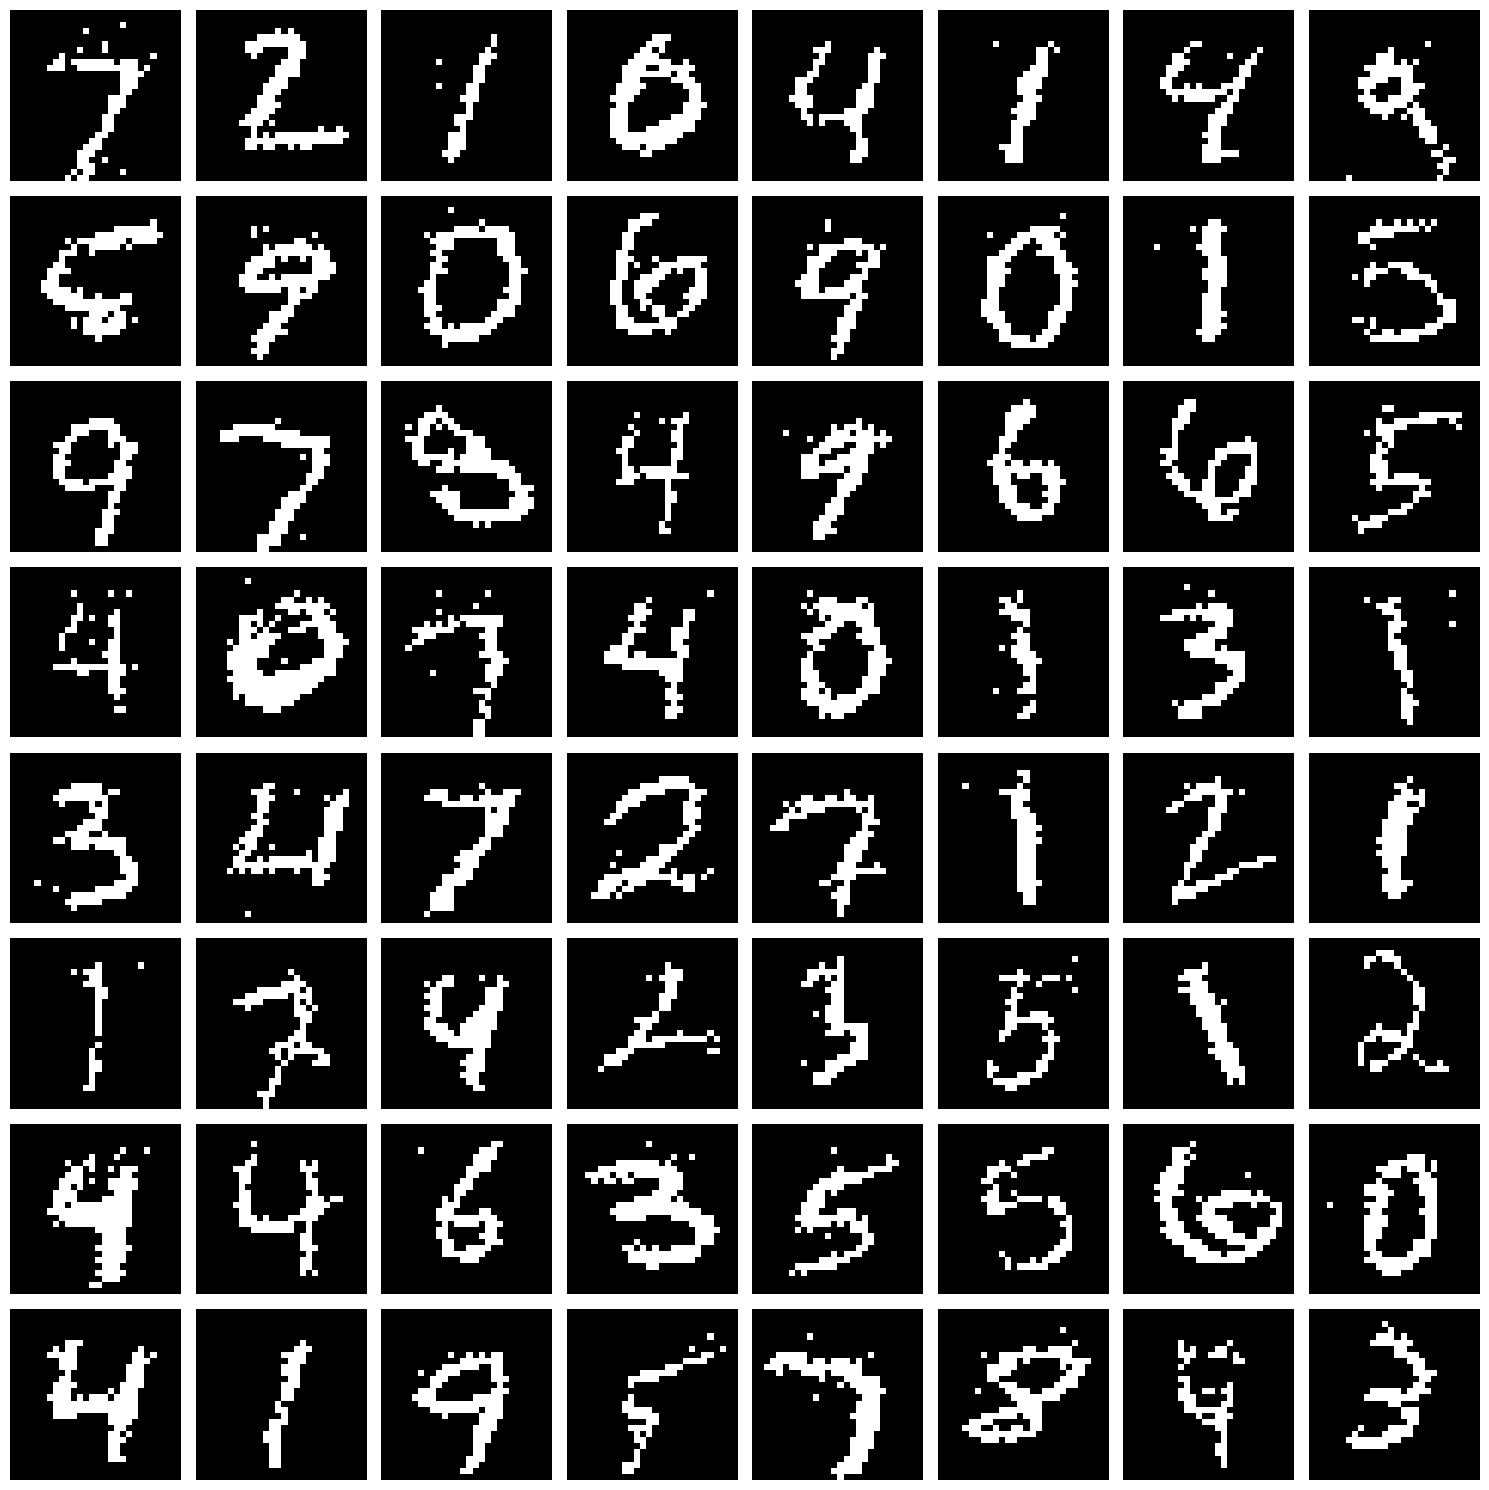

In [31]:
H, W = 28, 28

with torch.no_grad():
    for iter, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        pred = model(images)

        for i in range(H):
            for j in range(W):
                pred[:, :, i, j] = torch.bernoulli(
                    pred[:, :, i, j], out=pred[:, :, i, j]
                )
        break

samples = pred.detach().cpu().numpy().transpose(0, 2, 3, 1)
fig, axes = plt.subplots(8, 8, figsize=(15, 15))

for i in range(64):
    sample = samples[i]
    row, col = divmod(i, 8)
    axes[row, col].imshow(sample, cmap="gray")
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# f. Evaluation (Generation)


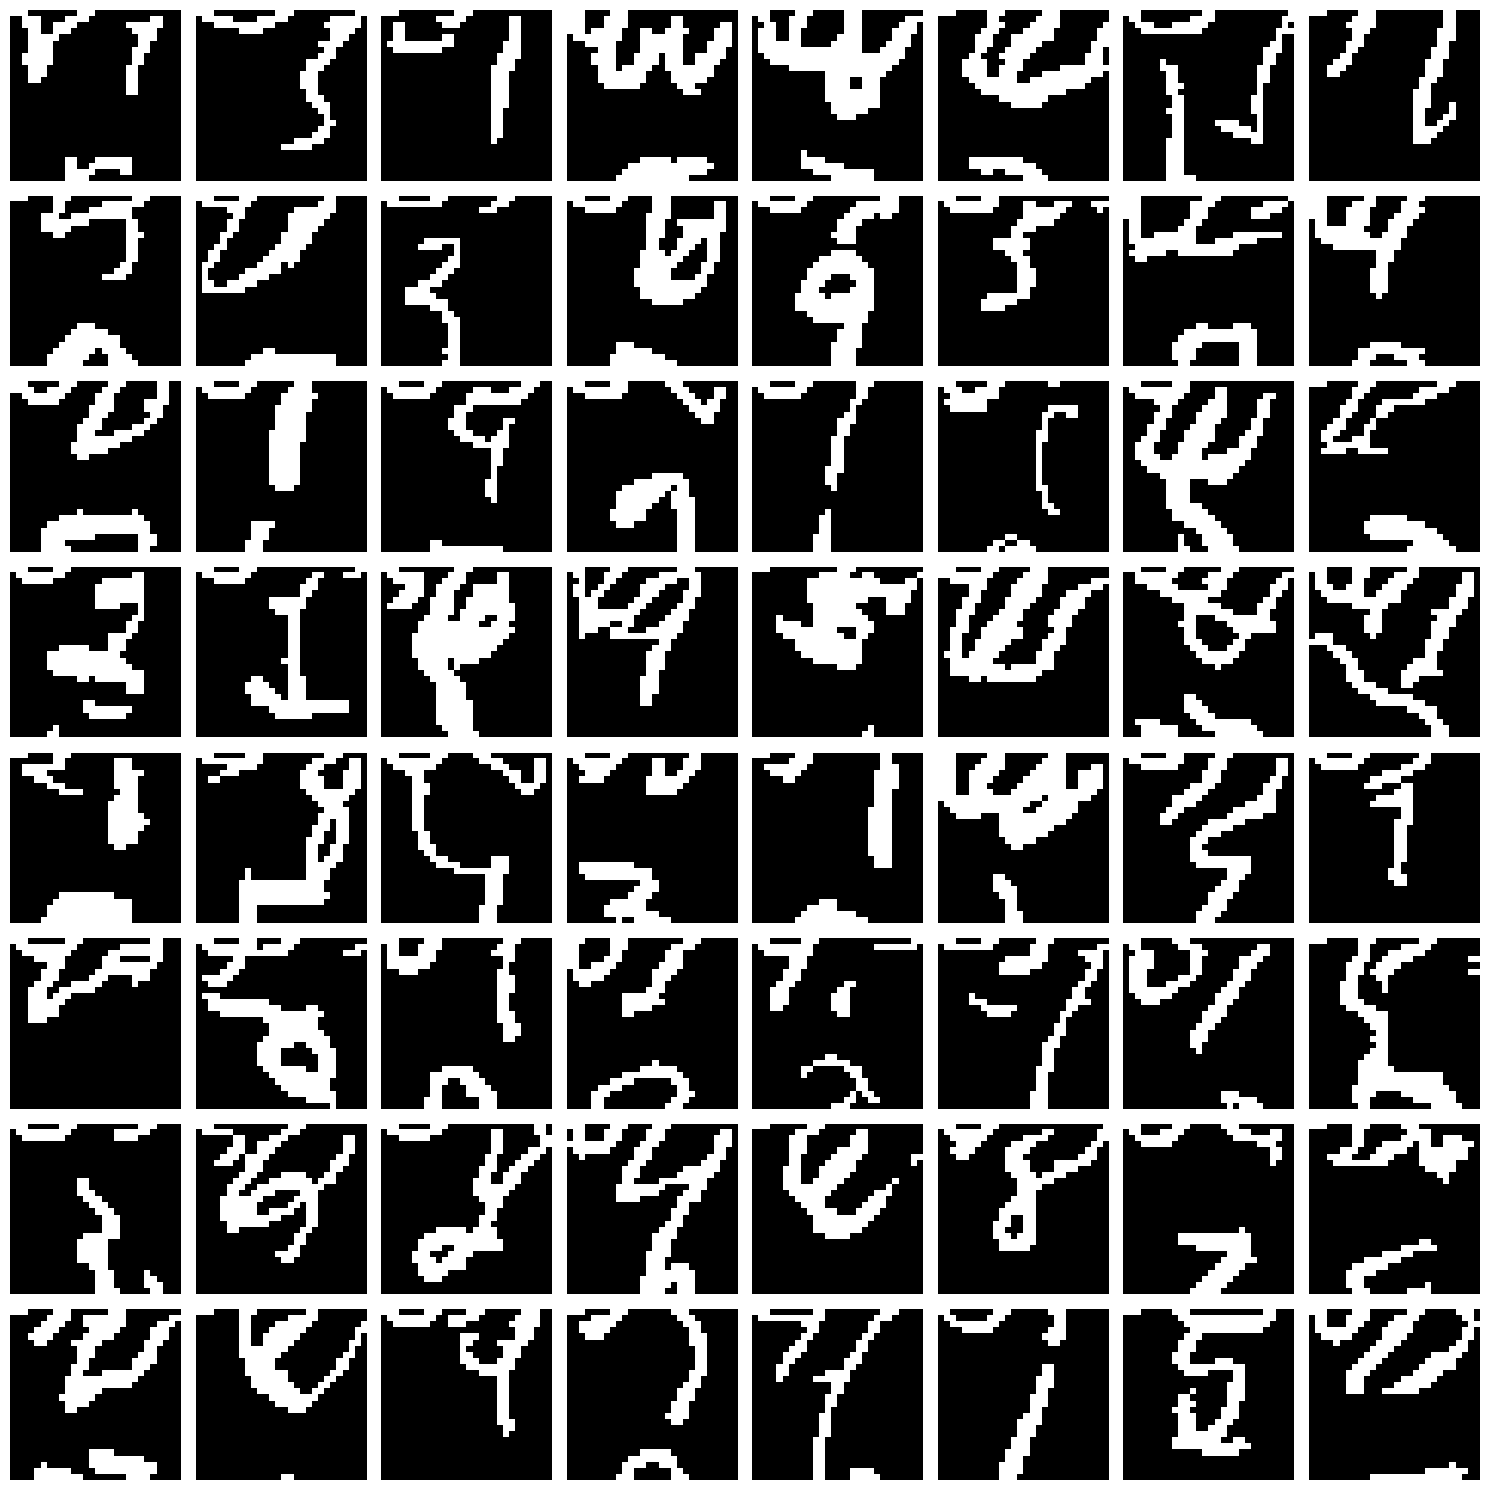

In [32]:
samples = torch.zeros(size=(64, 1, H, W)).to(device)
with torch.no_grad():
    for i in range(H):
        for j in range(W):
            # if j > 0 and i > 0:
            out = model(samples)
            samples[:, :, i, j] = torch.bernoulli(
                out[:, :, i, j], out=samples[:, :, i, j]
            )

samples = samples.cpu().numpy().transpose(0, 2, 3, 1)
fig, axes = plt.subplots(8, 8, figsize=(15, 15))

for i in range(64):
    sample = samples[i]
    row, col = divmod(i, 8)
    axes[row, col].imshow(sample, cmap="gray")
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# **2. Conditional PixelCNN**

# a. Training Function


In [30]:
def train_cond(dataloader, model, optimizer, epochs, n_classes):
    losses = []

    for epoch in tqdm(range(epochs), desc="Epochs"):
        running_loss = 0.0
        batch_progress = tqdm(dataloader, desc="Batches", leave=False)

        for iter, (images, labels) in enumerate(batch_progress):
            images = images.to(device)
            labels = labels.to(device)
            tgt = images.clone()
            labels = F.one_hot(labels, num_classes=n_classes).float()
            pred = model(images, labels)
            loss = bce(pred, tgt)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            avg_loss = running_loss * batch_size / len(train_dataset)
            losses.append(loss.item())

        tqdm.write(
            f"----\nEpoch [{epoch + 1}/{epochs}], Average Loss: {avg_loss:.4f}\n"
        )

    return losses

# b. Conditional Masked Convolution


In [34]:
class ConditionalMaskedConv2d(MaskedConv2d):
    ##################
    ### Problem 3(b): Implement ConditionalMaskedConv2d
    def __init__(self, num_classes, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.condition_weight = nn.Parameter(
            torch.randn(self.out_channels, num_classes))
        
        
    def forward(self, x, class_condition):
        condition_result = F.linear(class_condition, self.condition_weight)
        return super().forward(x) + condition_result.unsqueeze(-1).unsqueeze(-1)

    ##################

# c. Model


In [35]:
class ConditionalConvBlock(nn.Module):
    def __init__(self, num_classes, mask_type, in_channels, out_channels, kernel_size, padding=None, stride=1):
        super().__init__()
        if padding is None:
            padding = kernel_size // 2
        self.conv = ConditionalMaskedConv2d(
            num_classes=num_classes,
            mask_type=mask_type,
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x, class_condition):
        x = self.conv(x, class_condition)
        x = self.bn(x)
        x = self.relu(x)
        return x
    

class ConditionalPixelCNN(nn.Module):
    ##################
    ### Problem 3(b): Implement ConditionalPixelCNN

    def __init__(self, num_classes, in_channels=1, hidden_features=128, out_channels=1):
        super().__init__()
        self.blocks = nn.ModuleList([
            ConditionalConvBlock(num_classes, "A", in_channels, hidden_features, 7),
            ConditionalConvBlock(num_classes, "B", hidden_features, hidden_features, 3),
            ConditionalConvBlock(num_classes, "B", hidden_features, hidden_features, 3),
            ConditionalConvBlock(num_classes, "B", hidden_features, hidden_features, 3),
            ConditionalConvBlock(num_classes, "B", hidden_features, hidden_features, 3),
            ConditionalConvBlock(num_classes, "B", hidden_features, hidden_features, 3),
            ConditionalConvBlock(num_classes, "B", hidden_features, hidden_features, 3),
            ConditionalConvBlock(num_classes, "B", hidden_features, hidden_features, 3),
            ConditionalConvBlock(num_classes, "B", hidden_features, hidden_features, 3),
            ConditionalConvBlock(num_classes, "B", hidden_features, hidden_features, 3),
        ])

        self.out = nn.Sequential(
            nn.Conv2d(hidden_features, out_channels, 1), 
            nn.Sigmoid()
        )

    def forward(self, x, forward_condition):
        for block in self.blocks:
            x = block(x, forward_condition)
        return self.out(x)

    ##################

# d. Training


In [37]:
##################
epochs = 100
### Problem 3(c): Training
n_classes = 10
model = ConditionalPixelCNN(n_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

log = train_cond(train_loader, model, optimizer, epochs, n_classes)
##################


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [1/100], Average Loss: 0.1501



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [2/100], Average Loss: 0.0827



...

----
Epoch [98/100], Average Loss: 0.0625



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [99/100], Average Loss: 0.0624



Batches:   0%|          | 0/469 [00:00<?, ?it/s]

----
Epoch [100/100], Average Loss: 0.0623



# e. Evaluation (Reconstruction)


In [ ]:
H, W = 28, 28

with torch.no_grad():
    for iter, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        labels = labels.to(device)
        labels = F.one_hot(labels, num_classes=n_classes).float()
        pred = model(images, labels)

        for i in range(H):
            for j in range(W):
                pred[:, :, i, j] = torch.bernoulli(
                    pred[:, :, i, j], out=pred[:, :, i, j]
                )
        break

samples = pred.detach().cpu().numpy().transpose(0, 2, 3, 1)
fig, axes = plt.subplots(8, 8, figsize=(15, 15))

for i in range(64):
    sample = samples[i]
    row, col = divmod(i, 8)
    axes[row, col].imshow(sample, cmap="gray")
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# f. Evaluation (Generation)


In [ ]:
samples = torch.zeros(size=(60, 1, H, W)).to(device)
sample_classes = np.sort(np.array([np.arange(n_classes)] * 6).flatten())
sample_classes = (
    F.one_hot(torch.tensor(sample_classes), num_classes=n_classes).to(device).float()
)

with torch.no_grad():
    for i in range(H):
        for j in range(W):
            # if j > 0 and i > 0:
            out = model(samples, sample_classes)
            samples[:, :, i, j] = torch.bernoulli(
                out[:, :, i, j], out=samples[:, :, i, j]
            )

samples = samples.cpu().numpy().transpose(0, 2, 3, 1)
fig, axes = plt.subplots(10, 6, figsize=(15, 30))

for i in range(60):
    sample = samples[i]
    row, col = divmod(i, 6)
    axes[row, col].imshow(sample, cmap="gray")
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# Problem 4

## 4.1 Equivalance of MAP for $\theta$ and regularized ML estimator

$$
\begin{aligned}
\hat{\theta}_{\mathrm{MAP}}(\mathbf{x}) &= \arg\max_{\theta}\lbrack\log p(\theta\mid \mathbf{x}) \rbrack \\
&= \arg\max_{\theta}\lbrack\log\frac{p(\theta,\mathbf{x})}{p(\mathbf{x})} \rbrack \\
&= \arg\max_{\theta}\lbrack \log p(\theta,\mathbf{x}) \rbrack \\
&= \arg\max_{\theta}\lbrack \log p(\mathbf{x}\mid\theta)p(\theta) \rbrack \\
&= \arg\max_{\theta}\lbrack \log p(\mathbf{x};\theta) + \log p(\theta) \rbrack 
\end{aligned}
$$

Let $\rho(\theta) = -\frac{\log p(\theta)}{\lambda}$, we have 

$$
\hat{\theta}_{\mathrm{MAP}}(\mathbf{x}) = \arg\max_{\theta}\lbrack \log p(\mathbf{x};\theta) - \lambda\rho(\theta) \rbrack 
$$

The ML regualarizer is determinined by the prior

## 4.2 Equivalande of L2 regularization and Gaussian Prior

Gaussian prior (here $\theta$ represents one of the variables)

$$
\begin{aligned}
p(\theta)  &= \frac{1}{\sqrt{2\pi}\sigma}\exp\left\lbrack-\frac{(\theta-\mu)^2}{2\sigma^2}\right\rbrack \\
\log p(\theta) &= -\frac{(\theta-\mu)^2}{2\sigma^2} + C_1
\end{aligned}
$$

$C_1$ can be ignored. The equilavance holds when $\mu=0$ and $\lambda=\frac{1}{2\sigma^2}$